In [3]:
import pandas as pd
import numpy as np



,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Diet_Type_NonVegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,Blood_Group_A
0,37,26,111,198,99,72,5.5,1.7,1.6,4.4,...,1,0,1,0,1,0,1,0,0,0
1,37,24,121,199,103,75,4.5,1.9,2.6,5.6,...,1,2,2,0,0,1,1,0,0,0
2,81,27,135,199,100,74,12.1,2.9,2.6,1.8,...,0,1,0,1,0,0,0,0,0,1
3,25,21,150,199,102,70,4.3,1.0,1.7,5.2,...,1,2,0,1,0,0,0,1,0,0
4,24,26,146,202,99,76,16.0,5.0,3.4,1.4,...,2,0,2,0,1,0,0,1,0,0


In [4]:
# Load the Excel file
df = pd.read_excel('health_data.xlsx')

# Quick look at data
df.head()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Diet_Type_NonVegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O,Blood_Group_A
0,37,26,111,198,99,72,5.5,1.7,1.6,4.4,...,1,0,1,0,1,0,1,0,0,0
1,37,24,121,199,103,75,4.5,1.9,2.6,5.6,...,1,2,2,0,0,1,1,0,0,0
2,81,27,135,199,100,74,12.1,2.9,2.6,1.8,...,0,1,0,1,0,0,0,0,0,1
3,25,21,150,199,102,70,4.3,1.0,1.7,5.2,...,1,2,0,1,0,0,0,1,0,0
4,24,26,146,202,99,76,16.0,5.0,3.4,1.4,...,2,0,2,0,1,0,0,1,0,0


In [5]:
numeric_cols = ['Age','BMI','Blood_Pressure','Cholesterol','Glucose_Level',
                'Heart_Rate','Sleep_Hours','Exercise_Hours','Water_Intake','Stress_Level']

In [6]:
# IQR (Interquartile Range) is the range between the 75th percentile (Q3) and 25th percentile (Q1), measuring the spread of the middle 50% of the data.

In [7]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} → {len(outliers)} outliers")

Age → 773 outliers
BMI → 17 outliers
Blood_Pressure → 202 outliers
Cholesterol → 328 outliers
Glucose_Level → 58 outliers
Heart_Rate → 5 outliers
Sleep_Hours → 0 outliers
Exercise_Hours → 0 outliers
Water_Intake → 26 outliers
Stress_Level → 4 outliers


In [ ]:
# Handling outliers. (cap/winsorize)

In [8]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

In [9]:
#check outliers after capping

In [10]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col} → {len(outliers)} outliers after capping")

Age → 0 outliers after capping
BMI → 0 outliers after capping
Blood_Pressure → 0 outliers after capping
Cholesterol → 0 outliers after capping
Glucose_Level → 0 outliers after capping
Heart_Rate → 0 outliers after capping
Sleep_Hours → 0 outliers after capping
Exercise_Hours → 0 outliers after capping
Water_Intake → 0 outliers after capping
Stress_Level → 0 outliers after capping


In [11]:
#Scale Numeric Columns (Required for KNN)

In [12]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Age','BMI','Blood_Pressure','Cholesterol','Glucose_Level',
                'Heart_Rate','Sleep_Hours','Exercise_Hours','Water_Intake','Stress_Level']

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [13]:
#Split Features and Target

In [14]:
X = df.drop('Target', axis=1)  # All columns except Target
y = df['Target']               # Target column (0=Healthy, 1=Unhealthy)

In [15]:
#Train/Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
#Train KNN Model

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)  # start with k=5
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [19]:
#Evaluate Model

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.802
[[820 187]
 [209 784]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      1007
           1       0.81      0.79      0.80       993

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



In [ ]:
#KNN improvement

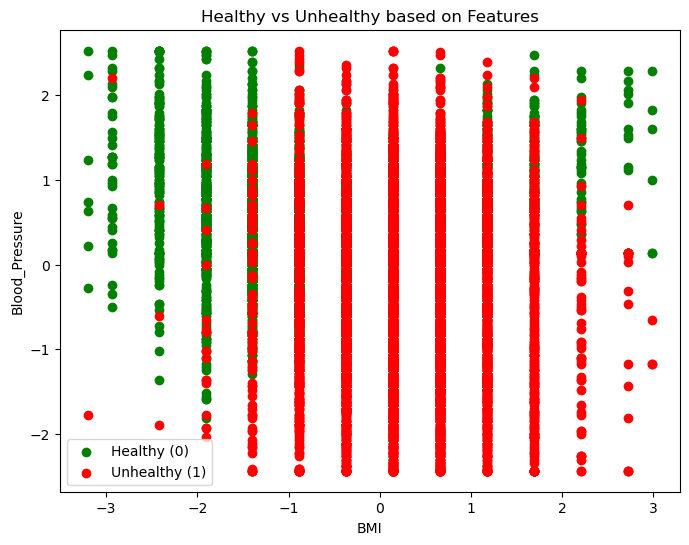

In [21]:
import matplotlib.pyplot as plt

# Pick two features from X to plot
feature1 = 'BMI'
feature2 = 'Blood_Pressure'

plt.figure(figsize=(8,6))
plt.scatter(X[feature1][y==0], X[feature2][y==0], color='green', label='Healthy (0)')
plt.scatter(X[feature1][y==1], X[feature2][y==1], color='red', label='Unhealthy (1)')

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title('Healthy vs Unhealthy based on Features')
plt.legend()
plt.show()

In [22]:
#python code to try multiple ks

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score

best_k = 0
best_recall = 0

for k in range(1, 21):  # try k from 1 to 20
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    recall = recall_score(y_test, y_pred, pos_label=1)  # recall for Unhealthy
    print(f"k={k}, Unhealthy Recall={recall:.3f}")
    
    if recall > best_recall:
        best_recall = recall
        best_k = k

print(f"Best k={best_k} with Unhealthy Recall={best_recall:.3f}")

k=1, Unhealthy Recall=0.747
k=2, Unhealthy Recall=0.593
k=3, Unhealthy Recall=0.776
k=4, Unhealthy Recall=0.680
k=5, Unhealthy Recall=0.790
k=6, Unhealthy Recall=0.722
k=7, Unhealthy Recall=0.806
k=8, Unhealthy Recall=0.769
k=9, Unhealthy Recall=0.820
k=10, Unhealthy Recall=0.771
k=11, Unhealthy Recall=0.816
k=12, Unhealthy Recall=0.768
k=13, Unhealthy Recall=0.817
k=14, Unhealthy Recall=0.779
k=15, Unhealthy Recall=0.818
k=16, Unhealthy Recall=0.792
k=17, Unhealthy Recall=0.818
k=18, Unhealthy Recall=0.797
k=19, Unhealthy Recall=0.815
k=20, Unhealthy Recall=0.791
Best k=9 with Unhealthy Recall=0.820


In [26]:
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8285
[[843 164]
 [179 814]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1007
           1       0.83      0.82      0.83       993

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



In [27]:

from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=9, weights='distance')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8285
[[843 164]
 [179 814]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1007
           1       0.83      0.82      0.83       993

    accuracy                           0.83      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.83      0.83      0.83      2000



In [29]:
#resample the training set:

In [30]:
from sklearn.utils import resample

# Separate classes
df_train = pd.concat([X_train, y_train], axis=1)
df_majority = df_train[df_train.Target==0]
df_minority = df_train[df_train.Target==1]

# Upsample minority
df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_train_balanced = pd.concat([df_majority, df_minority_upsampled])
X_train_balanced = df_train_balanced.drop('Target', axis=1)
y_train_balanced = df_train_balanced['Target']

In [31]:
#train knn on balanced data
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=9)  # or best k you found
knn.fit(X_train_balanced, y_train_balanced)

KNeighborsClassifier(n_neighbors=9)

In [32]:
#predict on test data
y_pred = knn.predict(X_test)

In [33]:
#evaluate model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8205
[[847 160]
 [199 794]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83      1007
           1       0.83      0.80      0.82       993

    accuracy                           0.82      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.82      0.82      0.82      2000



In [34]:
#Summary
#Recall for Unhealthy (82%) is critical:
#Model correctly identifies most high-risk individuals
#False Negatives reduced to 179:
#Fewer unhealthy applicants incorrectly classified as healthy

In [35]:
#use cross validation

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

best_k = 0
best_score = 0

for k in range(1, 21):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(pipeline, X, y, cv=5, scoring='recall')
    mean_score = scores.mean()
    
    print(f"k={k}, Recall={mean_score:.3f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_k = k

print(f"Best k={best_k}, Best Recall={best_score:.3f}")

k=1, Recall=0.702
k=2, Recall=0.507
k=3, Recall=0.724
k=4, Recall=0.599
k=5, Recall=0.729
k=6, Recall=0.639
k=7, Recall=0.744
k=8, Recall=0.663
k=9, Recall=0.747
k=10, Recall=0.681
k=11, Recall=0.750
k=12, Recall=0.693
k=13, Recall=0.758
k=14, Recall=0.712
k=15, Recall=0.762
k=16, Recall=0.721
k=17, Recall=0.764
k=18, Recall=0.726
k=19, Recall=0.771
k=20, Recall=0.730
Best k=19, Best Recall=0.771


In [37]:
#check with k=19

In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Train with k=19
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.835
[[861 146]
 [184 809]]
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      1007
           1       0.85      0.81      0.83       993

    accuracy                           0.83      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.84      0.83      0.83      2000



In [42]:
#“Although k=19 gave slightly higher accuracy, I selected k=9 because it had better recall for the unhealthy class, which is critical for minimizing insurance risk.”

In [43]:
#AUC ROC calculation. 

In [ ]:
#Train both models

In [44]:
from sklearn.neighbors import KNeighborsClassifier

# Model 1: k = 9
knn9 = KNeighborsClassifier(n_neighbors=9)
knn9.fit(X_train, y_train)

# Model 2: k = 19
knn19 = KNeighborsClassifier(n_neighbors=19)
knn19.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=19)

In [45]:
#Get probability scores

In [46]:
# Probability of class 1 (Unhealthy)
y_prob_9 = knn9.predict_proba(X_test)[:,1]
y_prob_19 = knn19.predict_proba(X_test)[:,1]

In [47]:
#Calculate AUC

In [48]:
from sklearn.metrics import roc_auc_score

auc_9 = roc_auc_score(y_test, y_prob_9)
auc_19 = roc_auc_score(y_test, y_prob_19)

print("AUC for k=9:", auc_9)
print("AUC for k=19:", auc_19)

AUC for k=9: 0.9038452884191325
AUC for k=19: 0.912188697246165


In [49]:
#For insurance use case, Missing unhealthy people = high risk So priority = Recall (Unhealthy). So choosing k=9 is better.